# 📊 01 — Data Exploration
**QuantumCrop · QC² Hackathon 2026**

This notebook explores the PlantVillage dataset:
- Class distribution
- Sample images per class
- Feature vector distributions
- NDVI vs disease correlation

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

from utils.config import CFG
from data.loader import load_dataset
from data.preprocess import extract_features, build_feature_matrix

print('CFG loaded. Classes:', CFG.CLASSES)

C:\Users\balaj\AppData\Local\Programs\Python\Python38\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: Could not find module 'C:\Users\balaj\AppData\Local\Programs\Python\Python38\Lib\site-packages\torchvision\image.pyd' (or one of its dependencies). Try using the full path with constructor syntax.
  warn(f"Failed to load image Python extension: {e}")


CFG loaded. Classes: None


## 1. Load Dataset

In [2]:
train_rec, val_rec, test_rec = load_dataset(max_per_class=None)
all_rec = train_rec + val_rec + test_rec
print(f'Total images: {len(all_rec)}')

  Auto-discovered 101 classes in MasterDataset/


Dataset loaded → train: 79538, val: 11362, test: 22725
  Train class distribution:
    [0] american_bollworm_on_cotton    → 59 images
    [1] anthracnose_on_cotton          → 21 images
    [2] apple_apple_scab               → 1418 images
    [3] apple_black_rot                → 1407 images
    [4] apple_cedar_apple_rust         → 1227 images
    [5] apple_healthy                  → 1420 images
    [6] army_worm                      → 242 images
    [7] bacterial_blight_in_cotton     → 347 images
    [8] becterial_blight_in_rice       → 1093 images
    [9] bell_pepper_bacterial_spot     → 1317 images
    [10] bell_pepper_healthy            → 1350 images
    [11] blueberry_healthy              → 1252 images
    [12] bollrot_on_cotton              → 1 images
    [14] brownspot                      → 1154 images
    [15] cherry_healthy                 → 1302 images
    [16] cherry_including_sour_healthy  → 1270 images
    [17] cherry_including_sour_powdery_mildew → 1166 images
    [18] che

## 2. Class Distribution

C:\Users\balaj\AppData\Local\Temp\ipykernel_31816\1188482082.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([c.replace('_',' ') for c in class_names], rotation=15)


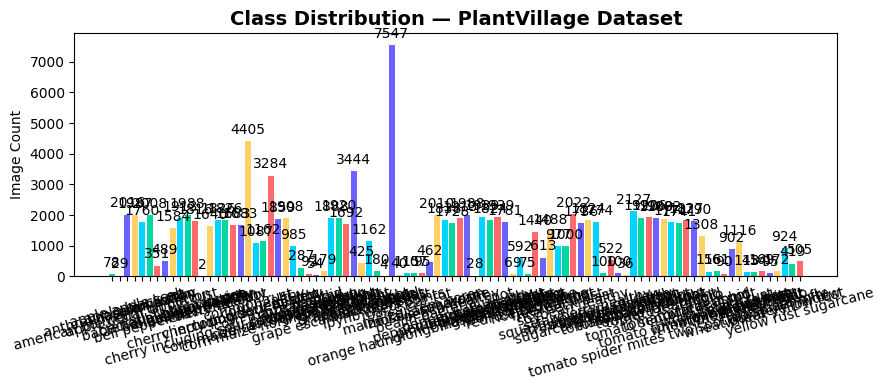

In [3]:
label_counts = Counter(label for _, label in all_rec)
class_names  = [CFG.CLASSES[i] for i in sorted(label_counts)]
counts       = [label_counts[i] for i in sorted(label_counts)]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(class_names, counts, color=['#06D6A0','#FF6B6B','#6C63FF','#FFD166','#00D4FF'])
ax.bar_label(bars, padding=3)
ax.set_title('Class Distribution — PlantVillage Dataset', fontsize=14, fontweight='bold')
ax.set_ylabel('Image Count')
ax.set_xticklabels([c.replace('_',' ') for c in class_names], rotation=15)
plt.tight_layout()
plt.savefig('../outputs/plots/class_distribution.png', dpi=150)
plt.show()

## 3. Sample Images Per Class

C:\Users\balaj\AppData\Local\Temp\ipykernel_31816\616297386.py:13: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


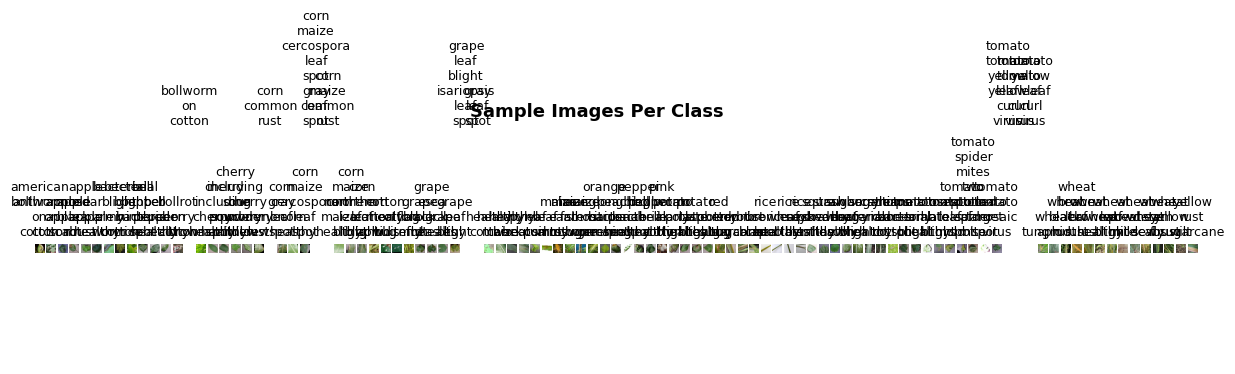

In [4]:
by_class = {i: [] for i in range(CFG.NUM_CLASSES)}
for path, label in all_rec:
    by_class[label].append(path)

fig, axes = plt.subplots(1, CFG.NUM_CLASSES, figsize=(15, 3))
for i, ax in enumerate(axes):
    if by_class[i]:
        img = Image.open(by_class[i][0]).resize((128, 128))
        ax.imshow(img)
    ax.set_title(CFG.CLASSES[i].replace('_','\n'), fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Images Per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/sample_images.png', dpi=150)
plt.show()

## 4. Feature Vector Distributions

Extracting features (this may take a minute)...


Exploring features:   0%|                                                           | 0/200 [00:00<?, ?it/s]

Exploring features:  12%|█████▉                                           | 24/200 [00:00<00:01, 120.91it/s]

Exploring features:  24%|████████████                                     | 49/200 [00:00<00:00, 174.08it/s]

Exploring features:  36%|█████████████████▋                               | 72/200 [00:00<00:00, 193.83it/s]

...

Exploring features:  90%|███████████████████████████████████████████▏    | 180/200 [00:00<00:00, 187.50it/s]

Exploring features: 100%|████████████████████████████████████████████████| 200/200 [00:01<00:00, 175.24it/s]

Exploring features: 100%|████████████████████████████████████████████████| 200/200 [00:01<00:00, 180.81it/s]

C:\Users\balaj\AppData\Local\Programs\Python\Python38\lib\site-packages\numpy\lib\histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


C:\Users\balaj\AppData\Local\Temp\ipykernel_31816\1529395722.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


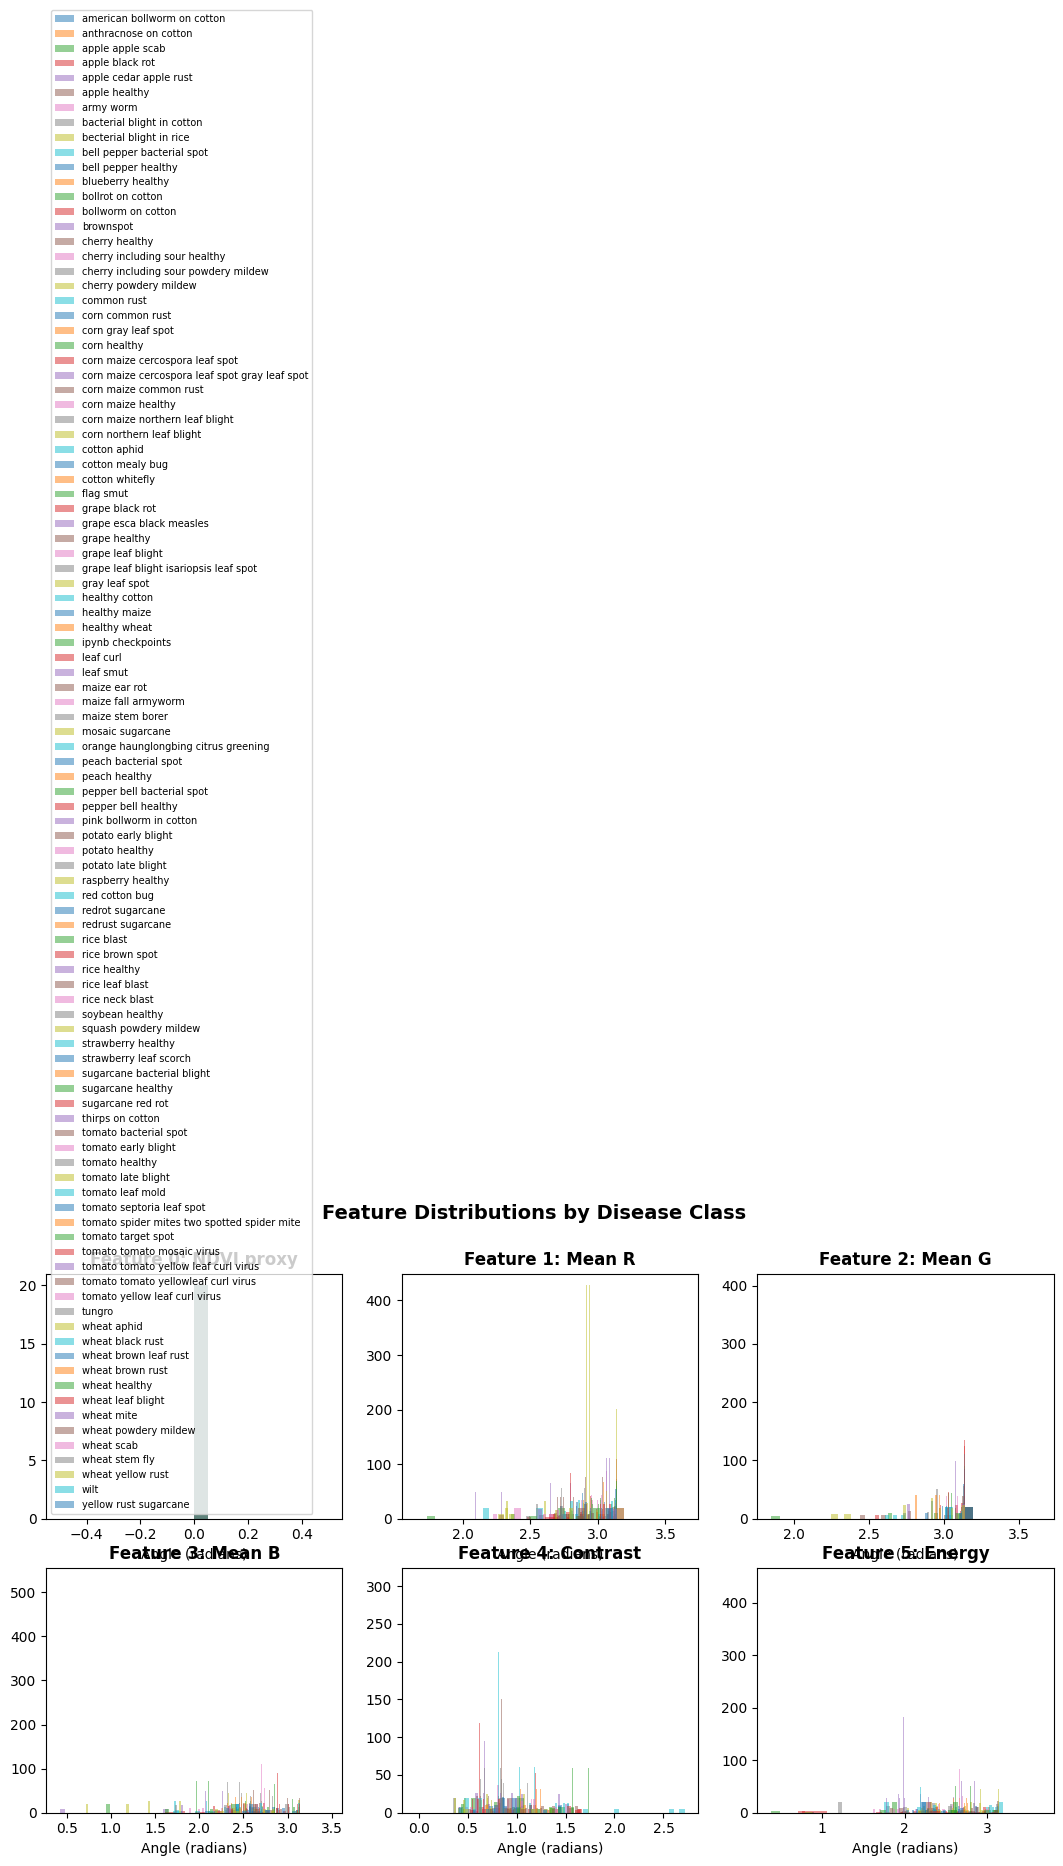

In [5]:
print('Extracting features (this may take a minute)...')
X, y = build_feature_matrix(all_rec[:200], desc='Exploring features')

feat_names = ['NDVI proxy', 'Mean R', 'Mean G', 'Mean B', 'Contrast', 'Energy']
colors     = ['#06D6A0','#FF6B6B','#6C63FF','#FFD166','#00D4FF','#F4A261']

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for i, (ax, name, color) in enumerate(zip(axes.flat, feat_names, colors)):
    for cls_idx, cls_name in enumerate(CFG.CLASSES):
        mask = y == cls_idx
        ax.hist(X[mask, i], bins=20, alpha=0.5, label=cls_name.replace('_',' '), density=True)
    ax.set_title(f'Feature {i}: {name}', fontweight='bold')
    ax.set_xlabel('Angle (radians)')
    if i == 0: ax.legend(fontsize=7)

plt.suptitle('Feature Distributions by Disease Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/feature_distributions.png', dpi=150)
plt.show()

## 5. NDVI vs Mean Green — Disease Separation

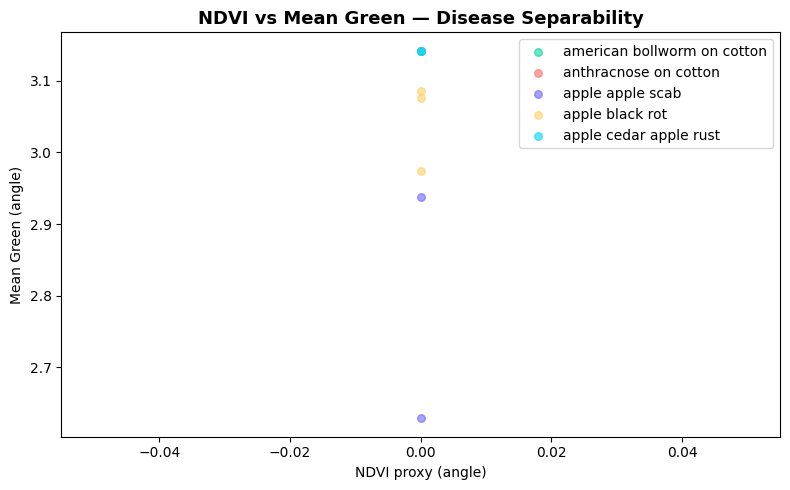


Key insight: Healthy crops cluster at high NDVI + high Green, diseased crops scatter lower.


In [6]:
palette = ['#06D6A0','#FF6B6B','#6C63FF','#FFD166','#00D4FF']
fig, ax = plt.subplots(figsize=(8, 5))
for cls_idx, (cls_name, color) in enumerate(zip(CFG.CLASSES, palette)):
    mask = y == cls_idx
    ax.scatter(X[mask, 0], X[mask, 2], label=cls_name.replace('_',' '),
               color=color, alpha=0.6, s=30)
ax.set_xlabel('NDVI proxy (angle)')
ax.set_ylabel('Mean Green (angle)')
ax.set_title('NDVI vs Mean Green — Disease Separability', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/ndvi_scatter.png', dpi=150)
plt.show()
print('\nKey insight: Healthy crops cluster at high NDVI + high Green, diseased crops scatter lower.')

## 6. Feature Correlation Heatmap

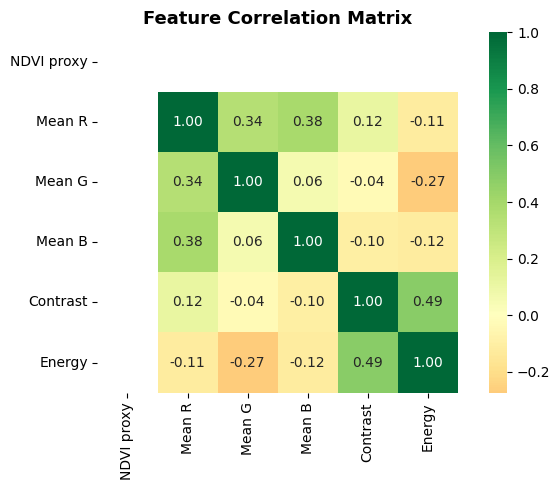


Note: Low inter-feature correlation → each qubit encodes independent information.


In [7]:
import pandas as pd
df = pd.DataFrame(X, columns=feat_names)
df['Disease'] = [CFG.CLASSES[i] for i in y]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[feat_names].corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/feature_correlation.png', dpi=150)
plt.show()
print('\nNote: Low inter-feature correlation → each qubit encodes independent information.')